In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import random
seed=42
np.random.seed(seed)
random.seed(seed)



In [2]:
train_df=pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')
x=train_df.drop('label',axis=1).values
y=train_df['label'].values
x_test=test_df.drop('label',axis=1).values
y_test=test_df['label'].values

In [3]:
x=x/255.0
x_test=x_test/255.0

In [4]:
print(x.shape)

(60000, 784)


In [5]:
x_train, x_val, y_train, y_val=train_test_split(x,y,test_size=0.2,random_state=seed, stratify=y)

In [6]:
print("Training samples: ", x_train.shape[0])
print("Validation samples: ", x_val.shape[0])
print("Test samples: ", x_test.shape[0])

Training samples:  48000
Validation samples:  12000
Test samples:  10000


In [7]:
def class_distribution(labels, name):
    counter=Counter(labels)
    print(f"\n{name} distribution: ")
    for cl, count in sorted(counter.items()):
        print(f"Class {cl} : {count}")
class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")


Train distribution: 
Class 0 : 4800
Class 1 : 4800
Class 2 : 4800
Class 3 : 4800
Class 4 : 4800
Class 5 : 4800
Class 6 : 4800
Class 7 : 4800
Class 8 : 4800
Class 9 : 4800

Validation distribution: 
Class 0 : 1200
Class 1 : 1200
Class 2 : 1200
Class 3 : 1200
Class 4 : 1200
Class 5 : 1200
Class 6 : 1200
Class 7 : 1200
Class 8 : 1200
Class 9 : 1200

Test distribution: 
Class 0 : 1000
Class 1 : 1000
Class 2 : 1000
Class 3 : 1000
Class 4 : 1000
Class 5 : 1000
Class 6 : 1000
Class 7 : 1000
Class 8 : 1000
Class 9 : 1000


<function matplotlib.pyplot.show(close=None, block=None)>

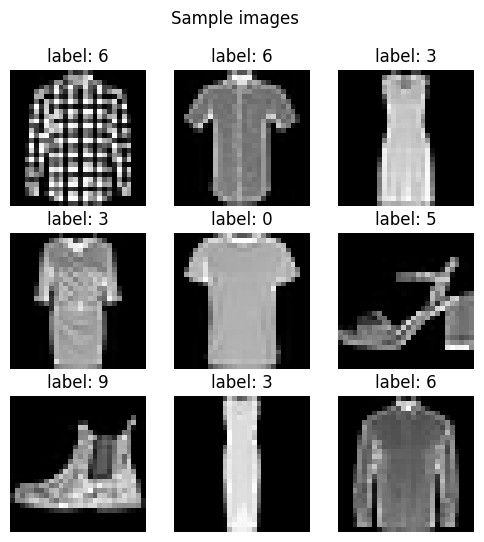

In [8]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='grey')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample images")
plt.show

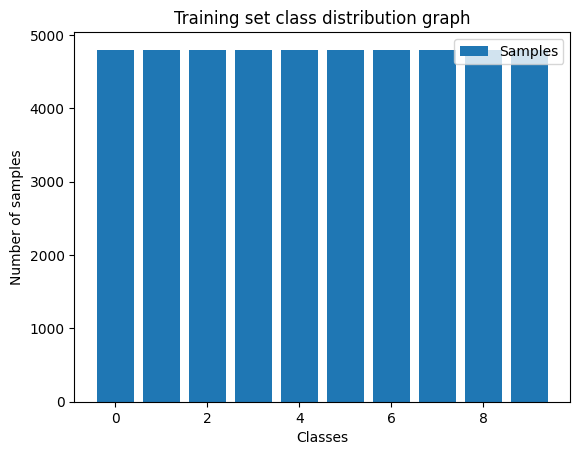

In [9]:
def plot_distribution(labels, title):
    counter=Counter(labels)
    classes=list(counter.keys())
    counts=list(counter.values())
    plt.figure()
    plt.bar(classes, counts)
    plt.xlabel("Classes")
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.legend(["Samples"])
    plt.show()
plot_distribution(y_train, "Training set class distribution graph")

**PART 1**

In [10]:
input_size=784
hidden_size=64
output_size=10
lr=0.01
w1=np.random.randn(input_size,hidden_size)*0.01
b1=np.zeros((1,hidden_size))
w2=np.random.randn(hidden_size,output_size)*0.01
b2=np.zeros((1,output_size))


In [11]:
def relu(x):
    return np.maximum(0,x)
def relu_deriv(x):
    return (x>0).astype(float)
def softmax(x):
    exp=np.exp(x-np.max(x,axis=1, keepdims=True))
    return exp/np.sum(exp,axis=1,keepdims=True)

In [12]:
def forward(x):
    z1=x@w1+b1
    a1=relu(z1)
    z2=a1@w2+b2
    a2=softmax(z2)
    return z1, a1,z2,a2
    

In [13]:
def compute_loss(y_true, y_pred):
    n=y_true.shape[0]
    log_like=-np.log(y_pred[range(n),y_true]+1e-9)
    return np.mean(log_like)

In [14]:
def backward(x, y, z1, a1, a2):
    n = x.shape[0]
    y_onehot = np.zeros_like(a2)
    y_onehot[np.arange(n), y] = 1
    dz2 = (a2 - y_onehot) / n
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ w2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [15]:
def update(dW1, db1, dW2, db2):
    global w1, b1, w2, b2
    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

In [16]:
X_sub = x_train[:5000]
y_sub = y_train[:5000]
losses = []
for epoch in range(20):
    z1, a1, z2, a2 = forward(X_sub)
    loss = compute_loss(y_sub, a2)
    losses.append(loss)
    dW1, db1, dW2, db2 = backward(X_sub, y_sub, z1, a1, a2)
    update(dW1, db1, dW2, db2)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 2.3044
Epoch 2, Loss: 2.3043
Epoch 3, Loss: 2.3041
Epoch 4, Loss: 2.3039
Epoch 5, Loss: 2.3038
Epoch 6, Loss: 2.3036
Epoch 7, Loss: 2.3035
Epoch 8, Loss: 2.3033
Epoch 9, Loss: 2.3031
Epoch 10, Loss: 2.3030
Epoch 11, Loss: 2.3028
Epoch 12, Loss: 2.3026
Epoch 13, Loss: 2.3025
Epoch 14, Loss: 2.3023
Epoch 15, Loss: 2.3022
Epoch 16, Loss: 2.3020
Epoch 17, Loss: 2.3018
Epoch 18, Loss: 2.3017
Epoch 19, Loss: 2.3015
Epoch 20, Loss: 2.3014


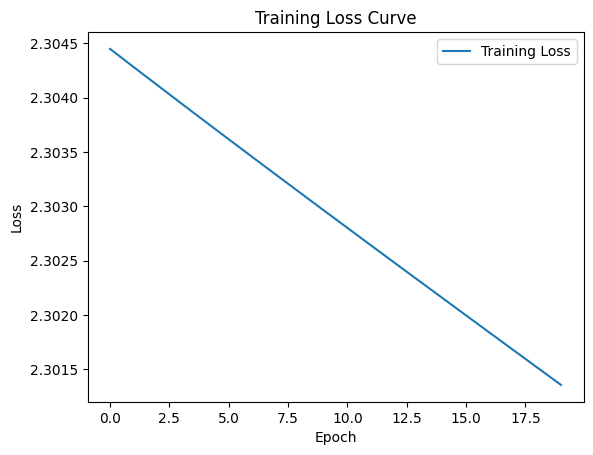

In [17]:
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

gradient check with pytorch

In [18]:
import torch
import torch.nn as nn
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [19]:
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(w1.T))
    model[0].bias.copy_(torch.tensor(b1.flatten()))  
    model[2].weight.copy_(torch.tensor(w2.T))
    model[2].bias.copy_(torch.tensor(b2.flatten()))

In [20]:
X_t = torch.tensor(X_sub[:32], dtype=torch.float32)
y_t = torch.tensor(y_sub[:32], dtype=torch.long)
criterion = nn.CrossEntropyLoss()
out = model(X_t)
loss_t = criterion(out, y_t)
loss_t.backward()

In [21]:
z1, a1, z2, a2 = forward(X_sub[:32])
dW1, db1, dW2, db2 = backward(X_sub[:32], y_sub[:32], z1, a1, a2)
torch_dW1 = model[0].weight.grad.numpy().T
torch_dW2 = model[2].weight.grad.numpy().T
print("Max diff W1:", np.max(np.abs(dW1 - torch_dW1)))
print("Max diff W2:", np.max(np.abs(dW2 - torch_dW2)))

Max diff W1: 6.567816182405373e-10
Max diff W2: 4.582193667904133e-09


the max abs difference between numpy and pytorch gradients is in 10^-10 which is extremely small confirming the backpropagation is correct and numerically stable.